In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
import warnings
warnings.filterwarnings('ignore') 
from tamaker_cov import TAMaker
import utils as util
from presets import COLLECTION_CENTRAL_3VIEW, COLLECTION_LATERAL_3VIEW, INDUCTION_V_3VIEW, INDUCTION_U_3VIEW
import numba
from tqdm import tqdm


import dunestyle.matplotlib as dunestyle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


DUNE plot style enabled


In [4]:

cos_tps0 = pd.read_parquet("./test_data/STtps_cosmics_plane0_009.parquet")
cos_tps1 = pd.read_parquet("./test_data/STtps_cosmics_plane1_009.parquet")
cos_tps2 = pd.read_parquet("./test_data/STtps_cosmics_plane2_009.parquet")


In [5]:
nu_itps = pd.read_pickle("./test_data/genie_nue_itps_9.pkl")
nu_tps = pd.read_pickle("./test_data/genie_nue_tps_9.pkl")

In [6]:
maker = TAMaker(**COLLECTION_CENTRAL_3VIEW)
util.get_unique_event_ids(nu_tps)
nu_tps['original_event'] = nu_tps.event
nu_tps.event = nu_tps.event_uid
nutas2, nutps2 = maker.run(nu_tps)

nu_tps= 0 

DBSCAN inspect: 100%|██████████| 9371/9371 [00:07<00:00, 1297.07it/s]


In [7]:
maker = TAMaker(**COLLECTION_CENTRAL_3VIEW)
cos_tps2['original_event'] = cos_tps2.event
cos_tps2.event = cos_tps2.event_uid
tas2, tps2 = maker.run(cos_tps2)

cos_tps2= 0 

DBSCAN inspect: 100%|██████████| 1918/1918 [00:01<00:00, 1730.39it/s]


In [8]:
maker = TAMaker(**INDUCTION_V_3VIEW)
cos_tps1['original_event'] = cos_tps1.event
cos_tps1.event = cos_tps1.event_uid
tas1, tps1 = maker.run(cos_tps1)
cos_tps1 = 0 

DBSCAN inspect: 100%|██████████| 3774/3774 [00:02<00:00, 1658.33it/s]


In [9]:
maker = TAMaker(**INDUCTION_V_3VIEW)
util.get_unique_event_ids(nu_itps)
nu_itps['original_event'] = nu_itps.event
nu_itps.event = nu_itps.event_uid
nutas1, nutps1 = maker.run(nu_itps)

maker = TAMaker(**INDUCTION_U_3VIEW)
nutas0, nutps0 = maker.run(nu_itps)

nu_itps=0

DBSCAN inspect: 100%|██████████| 12531/12531 [00:07<00:00, 1597.97it/s]


In [10]:
maker = TAMaker(**INDUCTION_U_3VIEW)
cos_tps0['original_event'] = cos_tps0.event
cos_tps0.event = cos_tps0.event_uid
tas0, tps0 = maker.run(cos_tps0)
cos_tps0 = 0 

DBSCAN inspect: 100%|██████████| 3610/3610 [00:02<00:00, 1620.89it/s]


# View Matching

In [11]:
IND_COLS = ["ch_wmean", "ch_wstd", "ch_t_wcov", "ch_p01", "ch_p99", "t_wmean", "t_wstd", "W"]

def view_match(tas0, tas1, tas2, ind_cut=1.5e3, col_cut=13e3, dt=200):
    keys = ["event", "run", "subrun", "window_start", "apa_id"]

    f0 = tas0[(tas0.max_cluster_energy > ind_cut) | (tas0.max_cluster_energy == -1)]
    f1 = tas1[(tas1.max_cluster_energy > ind_cut) | (tas1.max_cluster_energy == -1)]
    f2 = tas2[(tas2.max_cluster_energy > col_cut) | (tas2.max_cluster_energy == -1)]

    ind0 = f0[keys + IND_COLS].rename(columns={c: f"{c}_ind0" for c in IND_COLS})
    ind1 = f1[keys + IND_COLS].rename(columns={c: f"{c}_ind1" for c in IND_COLS})

    m02 = f2.merge(ind0, on=keys)
    m02 = m02[(m02.t_wmean - m02.t_wmean_ind0).abs() < dt]
    m02["dt"] = (m02.t_wmean - m02.t_wmean_ind0).abs()
    m02 = m02.loc[m02.groupby(keys)["dt"].idxmin()]
    m02 = m02[keys + [f"{c}_ind0" for c in IND_COLS]]

    m12 = f2.merge(ind1, on=keys)
    m12 = m12[(m12.t_wmean - m12.t_wmean_ind1).abs() < dt]
    m12["dt"] = (m12.t_wmean - m12.t_wmean_ind1).abs()
    m12 = m12.loc[m12.groupby(keys)["dt"].idxmin()]
    m12 = m12[keys + [f"{c}_ind1" for c in IND_COLS]]

    result = f2.merge(m02, on=keys, how="left")
    result = result.merge(m12, on=keys, how="left")

    has_ind0 = result["ch_wmean_ind0"].notna()
    has_ind1 = result["ch_wmean_ind1"].notna()
    matched  = has_ind0 | has_ind1
    result   = result[matched].copy()

    print(f"Matched 2-0 fraction:        {has_ind0.sum()/len(f2):.2f}")
    print(f"Matched 2-1 fraction:        {has_ind1.sum()/len(f2):.2f}")
    print(f"Matched 2-(0 OR 1) fraction: {matched.sum()/len(f2):.2f}")

    total = len(f2)

    print("0 match:", has_ind0.sum() / total)
    print("1 match:", has_ind1.sum() / total)
    print("both:", (has_ind0 & has_ind1).sum() / total)
    print("either:", matched.sum() / total)

    return result

col_tas_3view = view_match(tas0, tas1, tas2)

display(col_tas_3view)

Matched 2-0 fraction:        0.99
Matched 2-1 fraction:        0.99
Matched 2-(0 OR 1) fraction: 1.00
0 match: 0.9896969176612003
1 match: 0.9908560144243153
both: 0.9846741650210354
either: 0.9958787670644801


,event,run,subrun,apa_id,rop,window_start,flag,TA_id,total_window_energy,TP_count,...,t_wstd_ind0,W_ind0,ch_wmean_ind1,ch_wstd_ind1,ch_t_wcov_ind1,ch_p01_ind1,ch_p99_ind1,t_wmean_ind1,t_wstd_ind1,W_ind1
0,3732327248321,12737,869,8,3,0,2,1,7141999,168,...,195.675542,1833062.0,21597.717354,198.540538,21022.748745,21280.0671,22078.329,420.231119,195.009160,2388840.0
1,3732327248321,12737,869,9,3,0,2,2,2448445,77,...,78.502763,611733.0,24225.838159,79.861008,-2596.691672,23878.0245,24585.570,883.202379,74.677980,778381.0
2,3732327248321,12737,869,9,3,1000,2,3,15161012,376,...,122.245324,3211348.0,24331.898672,305.924745,25251.337661,23840.0000,24639.000,1283.851616,129.499428,3642122.0
3,3732328165825,12737,869,11,3,4000,2,6,499644,62,...,82.482001,106968.0,29539.540948,350.233866,-22481.835151,28960.0020,29758.980,4319.570152,92.262863,60198.0
4,3732328296897,12737,869,9,2,1000,2,9,6903334,207,...,172.704579,1270045.0,24041.503252,188.982057,14875.843420,23840.0521,24638.479,1562.375609,168.140189,1522220.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23289,42481523044801,12737,9891,8,3,3000,2,26749,38578,13,...,0.497574,3303.0,21394.325615,0.641499,-0.224546,21393.0002,21394.998,3884.805443,1.143806,4189.0
23290,42563127816641,12737,9910,2,3,2000,2,26771,51484,7,...,5.829399,11239.0,6417.683306,0.465187,1.947591,6417.0001,6417.999,2008.149753,4.186683,4247.0
23291,42618962391489,12737,9923,1,2,0,2,26789,30763,6,...,1.530966,6016.0,3696.020981,0.646072,-0.190383,3695.0002,3696.998,524.616283,0.795830,6768.0
23292,42636141146561,12737,9927,4,2,0,2,26804,13115,2,...,0.780817,3635.0,11597.889716,0.606511,-0.136748,11597.0002,11598.998,86.760036,0.970782,4434.0


In [12]:
nu_tas_3view = view_match(nutas0, nutas1, nutas2)

Matched 2-0 fraction:        0.96
Matched 2-1 fraction:        0.96
Matched 2-(0 OR 1) fraction: 0.97
0 match: 0.9584076366306514
1 match: 0.962656036924368
both: 0.9498583866568762
either: 0.9712052868981433


In [13]:
nu_tas_3view.to_pickle("./beam_nue_view_matched_tas.pkl")

In [14]:
col_tas_3view.to_pickle("./cosmic_view_matched_tas.pkl")

# yz Coordinate Extraction 

In [15]:
view_map = pd.DataFrame(np.loadtxt("./../YesOrNoTrigger/data/ViewChannelMatch_dunefd_1x2x6_full.txt", delimiter=","), columns=["col_ch", "ind_ch", "ind_plane", "y", "z"])
view_map = view_map.astype({"col_ch": np.int32, "ind_ch": np.int32, "ind_plane": np.int8})


In [16]:
WIRE_PITCH = 0.48  # cm
CM_PER_TICK = 0.08  # cm/tick
THETA = np.radians(35.7)
cos_t, sin_t = np.cos(THETA), np.sin(THETA)


@numba.njit
def _yz_lookup(vm_col, vm_ind, vm_y, vm_z, cl, ch, il, ih):
    n = len(cl)
    y_mean = np.full(n, np.nan)
    z_mean = np.full(n, np.nan)
    y_p01  = np.full(n, np.nan)
    y_p99  = np.full(n, np.nan)
    z_p01  = np.full(n, np.nan)
    z_p99  = np.full(n, np.nan)
    for i in range(n):
        lo = np.searchsorted(vm_col, cl[i])
        hi = np.searchsorted(vm_col, ch[i] + 1)
        if lo >= hi:
            continue
        count = 0
        sy = sz = 0.0
        ymin = ymax = zmin = zmax = 0.0
        for j in range(lo, hi):
            if vm_ind[j] < il[i] or vm_ind[j] > ih[i]:
                continue
            y, z = vm_y[j], vm_z[j]
            if count == 0:
                ymin = ymax = y
                zmin = zmax = z
            else:
                if y < ymin: ymin = y
                if y > ymax: ymax = y
                if z < zmin: zmin = z
                if z > zmax: zmax = z
            sy += y
            sz += z
            count += 1
        if count > 0:
            y_mean[i] = sy / count
            z_mean[i] = sz / count
            y_p01[i]  = ymin
            y_p99[i]  = ymax
            z_p01[i]  = zmin
            z_p99[i]  = zmax
    return y_mean, z_mean, y_p01, y_p99, z_p01, z_p99


def process_3d_features(col_tas_3view, view_map):
    df = col_tas_3view.copy()

    has_u = df["ch_wmean_ind0"].notna()
    has_v = df["ch_wmean_ind1"].notna()
    three_view = has_u & has_v
    u_only = has_u & ~has_v
    v_only = ~has_u & has_v

    df["x_mean"] = df["t_wmean"] * CM_PER_TICK * np.sign(df.bt_mu_x)

    col_w        = df["ch_wstd"].fillna(1.0)
    ind_wmean    = np.where(has_u, df["ch_wmean_ind0"], df["ch_wmean_ind1"])
    ind_wstd     = np.where(has_u, df["ch_wstd_ind0"].fillna(1.0), df["ch_wstd_ind1"].fillna(1.0))

    cl = (df["ch_wmean"] - col_w).round().astype(int).values
    ch = (df["ch_wmean"] + col_w).round().astype(int).values
    il = np.round(ind_wmean - ind_wstd).astype(int)
    ih = np.round(ind_wmean + ind_wstd).astype(int)

    col_sort_idx = np.argsort(view_map["col_ch"].values, kind="stable")
    vm_col = view_map["col_ch"].values[col_sort_idx].astype(np.int64)
    vm_ind = view_map["ind_ch"].values[col_sort_idx].astype(np.int64)
    vm_y   = view_map["y"].values[col_sort_idx].astype(np.float64)
    vm_z   = view_map["z"].values[col_sort_idx].astype(np.float64)

    print("JIT-compiling _yz_lookup (first call only)...")
    # Warm-up call on a single row so the tqdm run reflects true compute time
    _yz_lookup(vm_col, vm_ind, vm_y, vm_z,cl[:1].astype(np.int64), ch[:1].astype(np.int64), il[:1].astype(np.int64), ih[:1].astype(np.int64))
    print("Done. Running full lookup...")

    # Batch into chunks so tqdm gives meaningful progress
    batch = 500
    n = len(df)
    y_mean_arr = np.full(n, np.nan)
    z_mean_arr = np.full(n, np.nan)
    y_p01_arr  = np.full(n, np.nan)
    y_p99_arr  = np.full(n, np.nan)
    z_p01_arr  = np.full(n, np.nan)
    z_p99_arr  = np.full(n, np.nan)

    for start in tqdm(range(0, n, batch), desc="yz lookup"):
        end = min(start + batch, n)
        ym, zm, yp01, yp99, zp01, zp99 = _yz_lookup(
            vm_col, vm_ind, vm_y, vm_z,
            cl[start:end].astype(np.int64), ch[start:end].astype(np.int64),
            il[start:end].astype(np.int64), ih[start:end].astype(np.int64),
        )
        y_mean_arr[start:end] = ym
        z_mean_arr[start:end] = zm
        y_p01_arr[start:end]  = yp01
        y_p99_arr[start:end]  = yp99
        z_p01_arr[start:end]  = zp01
        z_p99_arr[start:end]  = zp99

    df["y_mean"] = y_mean_arr
    df["z_mean"] = z_mean_arr
    df["y_p01"]  = y_p01_arr
    df["y_p99"]  = y_p99_arr
    df["z_p01"]  = z_p01_arr
    df["z_p99"]  = z_p99_arr

    # ── Covariances ───────────────────────────────────────────────────────────
    W = df["W"]

    df["Cxx"] = (df["t_wstd"]  * CM_PER_TICK) ** 2 * W
    df["Czz"] = (df["ch_wstd"] * WIRE_PITCH)  ** 2 * W
    df["Cxz"] =  df["ch_t_wcov"] * WIRE_PITCH * CM_PER_TICK * W
    df["Cyy"] = np.nan
    df["Cyz"] = 0.0
    df["Cxy"] = 0.0

    s0_sq = (df["ch_wstd_ind0"] * WIRE_PITCH) ** 2 * W
    s1_sq = (df["ch_wstd_ind1"] * WIRE_PITCH) ** 2 * W

    if three_view.any():
        df.loc[three_view, "Cyz"] = (s0_sq[three_view] - s1_sq[three_view]) / (4 * cos_t * sin_t)
        df.loc[three_view, "Cyy"] = (s0_sq[three_view] + s1_sq[three_view]) / (2 * cos_t**2) - df.loc[three_view, "Czz"] * (sin_t / cos_t)**2
        df.loc[three_view, "Cxy"] = ((df["ch_t_wcov_ind0"] - df["ch_t_wcov_ind1"]) * WIRE_PITCH * CM_PER_TICK * W) / (2 * cos_t)

    if u_only.any():
        df.loc[u_only, "Cyy"] = (s0_sq[u_only] - df.loc[u_only, "Czz"] * sin_t**2) / cos_t**2
        df.loc[u_only, "Cxy"] = (df["ch_t_wcov_ind0"] * WIRE_PITCH * CM_PER_TICK * W) / cos_t

    if v_only.any():
        df.loc[v_only, "Cyy"] = (s1_sq[v_only] - df.loc[v_only, "Czz"] * sin_t**2) / cos_t**2
        df.loc[v_only, "Cxy"] = (df["ch_t_wcov_ind1"] * WIRE_PITCH * CM_PER_TICK * W) / (-cos_t)


    return df


reco_df = process_3d_features(col_tas_3view, view_map)
reco_nu = process_3d_features(nu_tas_3view, view_map)


JIT-compiling _yz_lookup (first call only)...
Done. Running full lookup...


yz lookup: 100%|██████████| 47/47 [00:02<00:00, 21.86it/s]


JIT-compiling _yz_lookup (first call only)...
Done. Running full lookup...


yz lookup: 100%|██████████| 38/38 [00:02<00:00, 15.59it/s]


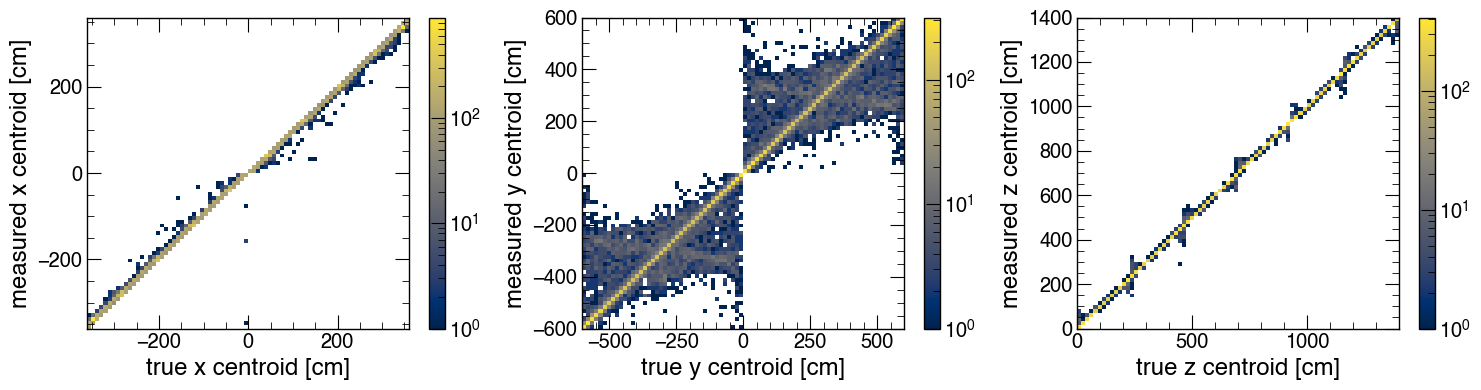

In [44]:
from matplotlib.colors import LogNorm
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
bins = 80

h = [ax[0].hist2d(reco_df.bt_mu_x, reco_df.x_mean,range=[(-360, 360), (-360, 360)], bins=bins, norm = LogNorm()),
     ax[1].hist2d(reco_df.bt_mu_y, reco_df.y_mean,range=[(-600, 600), (-600, 600)], bins=bins, norm = LogNorm()),
     ax[2].hist2d(reco_df.bt_mu_z, reco_df.z_mean,range=[(0, 1400), (0, 1400)], bins=bins,  norm = LogNorm())]

for a, hist, val in zip(ax, h, ['x', 'y', 'z']):
    fig.colorbar(hist[3], ax=a)
    a.set_xlabel(f"true {val} centroid [cm]")
    a.set_ylabel(f"measured {val} centroid [cm]")

plt.tight_layout()
plt.show()

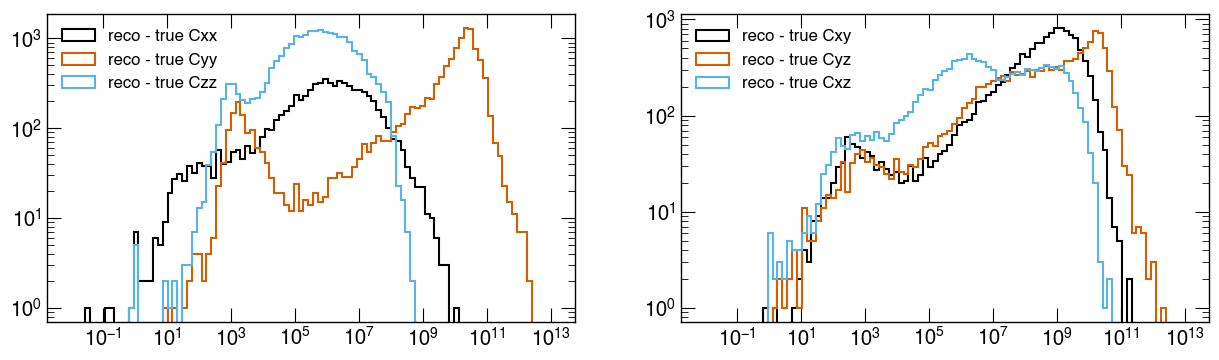

In [18]:
fig,ax = plt.subplots(1,2, figsize=(15,4))
bins = np.logspace(-2,13,100)
ax[0].hist(reco_df.Cxx - reco_df.bt_Cxx, bins = bins, histtype='step',label = 'reco - true Cxx')
ax[0].hist(reco_df.Cyy - reco_df.bt_Cyy, bins = bins, histtype='step', label = 'reco - true Cyy')
ax[0].hist(reco_df.Czz - reco_df.bt_Czz, bins = bins, histtype='step', label = 'reco - true Czz')


ax[1].hist(reco_df.Cxy - reco_df.bt_Cxy, bins = bins, histtype='step',label = 'reco - true Cxy')
ax[1].hist(reco_df.Cyz - reco_df.bt_Cyz, bins = bins, histtype='step', label = 'reco - true Cyz')
ax[1].hist(reco_df.Cxz - reco_df.bt_Cxz, bins = bins, histtype='step', label = 'reco - true Cxz')

for i in [0,1]:
    ax[i].set_yscale('log')
    ax[i].legend()
    ax[i].set_xscale('log')
plt.show()


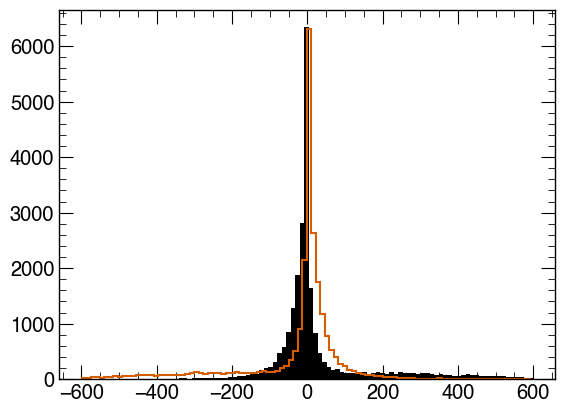

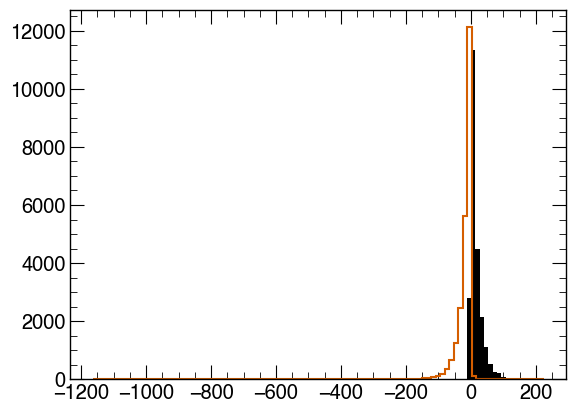

In [19]:
plt.hist(reco_df.bt_y_p01 - reco_df.y_p01, bins = 100)
plt.hist(reco_df.bt_y_p99 - reco_df.y_p99, histtype='step', bins = 100)
plt.show()

plt.hist(reco_df.bt_z_p99 - reco_df.z_p99, bins = 100)
plt.hist(reco_df.bt_z_p01 - reco_df.z_p01, histtype='step', bins = 100)
plt.show()


In [20]:

BOUNDS = {'x': (-360, 360), 'y': (-600, 600), 'z': (0, 1400)}
SENTINEL = -1

def near_walls(p, tau=20.0, bounds=BOUNDS):
    x, y, z = p
    walls = set()
    if x - bounds['x'][0] < tau: walls.add('x-')
    if bounds['x'][1] - x < tau: walls.add('x+')
    if y - bounds['y'][0] < tau: walls.add('y-')
    if bounds['y'][1] - y < tau: walls.add('y+')
    if z - bounds['z'][0] < tau: walls.add('z-')
    if bounds['z'][1] - z < tau: walls.add('z+')
    return walls

def compute_metrics_reco(df, tau=60.0, bounds=BOUNDS):
    """
    Compute A, V, B, alignment from view-matched TA windows.
    Uses reconstructed y, z (from channel view matching) but true x
    (bt_mu_x, bt_x_p01/p99) since drift reconstruction is not yet available.
    """
    sentinel = pd.Series({"a_score": float(SENTINEL), "b_score": float(SENTINEL), "v_score": float(SENTINEL), "alignment": float(SENTINEL)})

    # Drop windows with missing yz reconstruction or truth x
    required = ["y_mean", "z_mean", "x_mean", "W", "Cxx", "Cyy", "Czz", "Cxy", "Cxz", "Cyz"]
    df = df.dropna(subset=required)
    df = df[df["Cyy"] >= 0]   # guard against unphysical windows
    if len(df) < 2:
        return sentinel

    records = []
    for _, row in df.iterrows():
        W  = row["W"]
        mu = np.array([row["x_mean"], row["y_mean"], row["z_mean"]])

        C  = np.array([
            [row["Cxx"], row["Cxy"], row["Cxz"]], 
            [row["Cxy"], row["Cyy"], row["Cyz"]],
            [row["Cxz"], row["Cyz"], row["Czz"]],
        ])

        # Per-window principal axis and scalar extents from endpoints
        vals_i, vecs_i = np.linalg.eigh(C / max(W, 1e-12))
        u_i = vecs_i[:, np.argmax(vals_i)]

        # Endpoints: use true x for x-component, reco y/z
        p01 = np.array([row["bt_x_p01"], row["y_p01"], row["z_p01"]])
        p99 = np.array([row["bt_x_p99"], row["y_p99"], row["z_p99"]])
        s01 = float((p01 - mu) @ u_i)
        s99 = float((p99 - mu) @ u_i)

        records.append({"W": W, "mu": mu, "C": C,"u_i": u_i, "s01": s01, "s99": s99})

    # ── Parallel covariance merge ─────────────────────────────────────────────
    W_tot  = sum(r["W"] for r in records)
    mu_tot = sum(r["W"] * r["mu"] for r in records) / W_tot

    C_tot = np.zeros((3, 3))
    for r in records:
        delta  = r["mu"] - mu_tot
        C_tot += r["C"] + r["W"] * np.outer(delta, delta)
    C_tot /= W_tot

    vals, vecs = np.linalg.eigh(C_tot)
    idx  = np.argsort(vals)[::-1]
    vals = vals[idx]
    u    = vecs[:, idx[0]]

    A = vals[0] / (vals[1] + 1e-12)
    V = float(np.abs(u[1]))
    alignment = sum(r["W"] * abs(float(r["u_i"] @ u)) for r in records) / W_tot

    # ── Endpoints ────────────────────────────────────────────────────────────
    all_pts, all_sc = [], []
    for r in records:
        for s in [r["s01"], r["s99"]]:
            pt = r["mu"] + s * r["u_i"]
            all_pts.append(pt)
            all_sc.append(float((pt - mu_tot) @ u))

    all_pts = np.array(all_pts)
    all_sc  = np.array(all_sc)
    p_min   = all_pts[np.argmin(all_sc)]
    p_max   = all_pts[np.argmax(all_sc)]

    w1, w2 = near_walls(p_min, tau, bounds), near_walls(p_max, tau, bounds)
    if   len(w1) > 0 and len(w2) > 0 and w1.isdisjoint(w2): B = 2
    elif len(w1) > 0 or  len(w2) > 0:                        B = 1
    else:                                                      B = 0

    return pd.Series({"a_score": A, "b_score": float(B),
                      "v_score": V, "alignment": alignment})


def compute_metrics_truth(df, tau=30.0, bounds=BOUNDS):
    """
    Same merge but using pure truth bt_ columns throughout,
    for direct comparison against reco.
    """
    sentinel = pd.Series({"a_score": float(SENTINEL), "b_score": float(SENTINEL),
                          "v_score": float(SENTINEL), "alignment": float(SENTINEL)})

    required = ["bt_mu_x", "bt_mu_y", "bt_mu_z", "bt_W",
                "bt_Cxx", "bt_Cyy", "bt_Czz", "bt_Cxy", "bt_Cxz", "bt_Cyz"]
    df = df.dropna(subset=required)
    df = df[df["bt_W"] > 0]
    if len(df) < 2:
        return sentinel

    records = []
    for _, row in df.iterrows():
        W  = row["bt_W"]
        mu = np.array([row["bt_mu_x"], row["bt_mu_y"], row["bt_mu_z"]])
        C  = np.array([
            [row["bt_Cxx"], row["bt_Cxy"], row["bt_Cxz"]],
            [row["bt_Cxy"], row["bt_Cyy"], row["bt_Cyz"]],
            [row["bt_Cxz"], row["bt_Cyz"], row["bt_Czz"]],
        ])
        vals_i, vecs_i = np.linalg.eigh(C / max(W, 1e-12))
        u_i = vecs_i[:, np.argmax(vals_i)]
        p01 = np.array([row["bt_x_p01"], row["bt_y_p01"], row["bt_z_p01"]])
        p99 = np.array([row["bt_x_p99"], row["bt_y_p99"], row["bt_z_p99"]])
        s01 = float((p01 - mu) @ u_i)
        s99 = float((p99 - mu) @ u_i)
        records.append({"W": W, "mu": mu, "C": C,"u_i": u_i, "s01": s01, "s99": s99})

    W_tot  = sum(r["W"] for r in records)
    mu_tot = sum(r["W"] * r["mu"] for r in records) / W_tot

    C_tot = np.zeros((3, 3))
    for r in records:
        delta  = r["mu"] - mu_tot
        C_tot += r["C"] + r["W"] * np.outer(delta, delta)
    C_tot /= W_tot

    vals, vecs = np.linalg.eigh(C_tot)
    idx  = np.argsort(vals)[::-1]
    vals = vals[idx]
    u    = vecs[:, idx[0]]

    A = vals[0] / (vals[1] + 1e-12)
    V = float(np.abs(u[1]))
    alignment = sum(r["W"] * abs(float(r["u_i"] @ u)) for r in records) / W_tot

    all_pts, all_sc = [], []
    for r in records:
        for s in [r["s01"], r["s99"]]:
            pt = r["mu"] + s * r["u_i"]
            all_pts.append(pt)
            all_sc.append(float((pt - mu_tot) @ u))

    all_pts = np.array(all_pts)
    all_sc  = np.array(all_sc)
    p_min   = all_pts[np.argmin(all_sc)]
    p_max   = all_pts[np.argmax(all_sc)]

    w1, w2 = near_walls(p_min, tau, bounds), near_walls(p_max, tau, bounds)
    if   len(w1) > 0 and len(w2) > 0 and w1.isdisjoint(w2): B = 2
    elif len(w1) > 0 or  len(w2) > 0:                       B = 1
    else:                                                   B = 0

    return pd.Series({"a_score": A, "b_score": float(B), "v_score": V, "alignment": alignment})


# ── Run ───────────────────────────────────────────────────────────────────────

keys = ["event", "run", "subrun"]

cosmic_reco   = reco_df.groupby(keys).apply(compute_metrics_reco,  include_groups=False).reset_index()
cosmic_truth  = reco_df.groupby(keys).apply(compute_metrics_truth, include_groups=False).reset_index()


In [21]:

beam_reco   = reco_nu.groupby(keys).apply(compute_metrics_reco,  include_groups=False).reset_index()
beam_truth  = reco_nu.groupby(keys).apply(compute_metrics_truth, include_groups=False).reset_index()


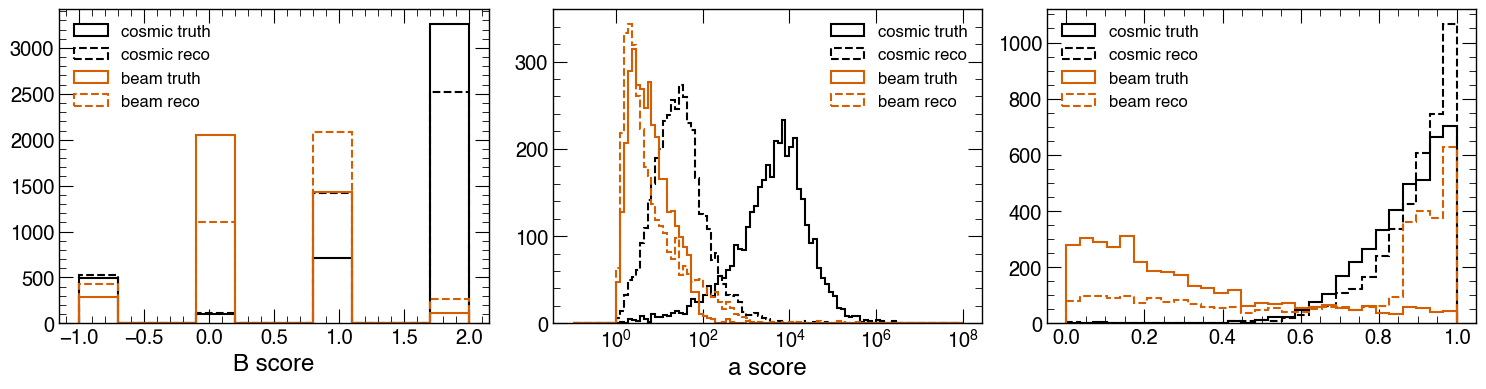

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# B score
ax = axes[0]
ax.hist(cosmic_truth.b_score, histtype='step', label='cosmic truth', color=colors[0])
ax.hist(cosmic_reco.b_score, histtype='step', label='cosmic reco', linestyle='--', color=colors[0])
ax.hist(beam_truth.b_score, histtype='step', label='beam truth', color=colors[1])
ax.hist(beam_reco.b_score, histtype='step', label='beam reco', linestyle='--', color=colors[1])
ax.set_xlabel("B score")
ax.legend()

# A score
ax = axes[1]
bins = np.logspace(-1, 8, 100)
ax.hist(cosmic_truth.a_score, histtype='step', bins=bins, color=colors[0], label='cosmic truth')
ax.hist(cosmic_reco.a_score, histtype='step', bins=bins, color=colors[0], linestyle='dashed', label='cosmic reco')
ax.hist(beam_truth.a_score, histtype='step', bins=bins, color=colors[1], label='beam truth')
ax.hist(beam_reco.a_score, histtype='step', bins=bins, color=colors[1], linestyle='dashed', label='beam reco')
ax.set_xlabel('a score')
ax.set_xscale('log')
ax.legend()

# V score
ax = axes[2]
bins = np.linspace(0, 1, 30)
ax.hist(cosmic_truth.v_score, histtype='step', bins=bins, color=colors[0], label='cosmic truth')
ax.hist(cosmic_reco.v_score, histtype='step', bins=bins, color=colors[0], linestyle='dashed', label='cosmic reco')
ax.hist(beam_truth.v_score, histtype='step', bins=bins, color=colors[1], label='beam truth')
ax.hist(beam_reco.v_score, histtype='step', bins=bins, color=colors[1], linestyle='dashed', label='beam reco')
ax.legend()

plt.tight_layout()
plt.show()

# gemini 

In [23]:
# ALL from look up map
def process_3d_features(col_tas_3view, view_map):
    df = col_tas_3view.copy()

    has_u = df["ch_wmean_ind0"].notna()
    has_v = df["ch_wmean_ind1"].notna()

    df["x_mean"] = df["t_wmean"] * CM_PER_TICK * np.sign(df.get("bt_mu_x", 1.0))

    col_w      = df["ch_wstd"].fillna(1.0)
    ind_wmean    = np.where(has_u, df["ch_wmean_ind0"], df["ch_wmean_ind1"])
    ind_wstd     = np.where(has_u, df["ch_wstd_ind0"].fillna(1.0), df["ch_wstd_ind1"].fillna(1.0))

    cl = (df["ch_wmean"] - col_w).round().astype(int).values
    ch = (df["ch_wmean"] + col_w).round().astype(int).values
    il = np.round(ind_wmean - ind_wstd).astype(int)
    ih = np.round(ind_wmean + ind_wstd).astype(int)

    col_sort_idx = np.argsort(view_map["col_ch"].values, kind="stable")
    vm_col = view_map["col_ch"].values[col_sort_idx].astype(np.int64)
    vm_ind = view_map["ind_ch"].values[col_sort_idx].astype(np.int64)
    vm_y   = view_map["y"].values[col_sort_idx].astype(np.float64)
    vm_z   = view_map["z"].values[col_sort_idx].astype(np.float64)

    batch = 500
    n = len(df)
    y_mean_arr = np.full(n, np.nan)
    z_mean_arr = np.full(n, np.nan)
    y_p01_arr  = np.full(n, np.nan)
    y_p99_arr  = np.full(n, np.nan)
    z_p01_arr  = np.full(n, np.nan)
    z_p99_arr  = np.full(n, np.nan)

    for start in tqdm(range(0, n, batch), desc="yz lookup"):
        end = min(start + batch, n)
        # Unpack exactly the 6 elements your current JIT function returns
        ym, zm, yp01, yp99, zp01, zp99 = _yz_lookup(
            vm_col, vm_ind, vm_y, vm_z,
            cl[start:end].astype(np.int64), ch[start:end].astype(np.int64),
            il[start:end].astype(np.int64), ih[start:end].astype(np.int64),
        )
        y_mean_arr[start:end] = ym
        z_mean_arr[start:end] = zm
        y_p01_arr[start:end]  = yp01
        y_p99_arr[start:end]  = yp99
        z_p01_arr[start:end]  = zp01
        z_p99_arr[start:end]  = zp99

    df["y_mean"] = y_mean_arr
    df["z_mean"] = z_mean_arr
    df["y_p01"]  = y_p01_arr
    df["y_p99"]  = y_p99_arr
    df["z_p01"]  = z_p01_arr
    df["z_p99"]  = z_p99_arr

    # ── 3D Covariances extracted directly from the spatial Map Bounds ─────────
    # We estimate spatial variance via the true geometry-mapped width floor
    # This completely bypasses the broken, wrap-around-blind analytical formulas.
    df["Cxx"] = (df["t_wstd"] * CM_PER_TICK) ** 2
    df["Cyy"] = np.maximum(((df["y_p99"] - df["y_p01"]) / 4.66) ** 2, 0.01)
    df["Czz"] = np.maximum(((df["z_p99"] - df["z_p01"]) / 4.66) ** 2, 0.01)
    df["Cyz"] = 0.0  # Kept uncorrelated at local level; global centroid movement recreates macroscopic Cyz
    
    # Track drift correlations from time projections
    df["Cxz"] = df["ch_t_wcov"] * WIRE_PITCH * CM_PER_TICK
    df["Cxy"] = np.where(has_u, 
                         df["ch_t_wcov_ind0"] * WIRE_PITCH * CM_PER_TICK, 
                         df["ch_t_wcov_ind1"] * WIRE_PITCH * CM_PER_TICK)

    return df
reco_df = process_3d_features(col_tas_3view, view_map = view_map)
reco_nu = process_3d_features(nu_tas_3view, view_map = view_map)

yz lookup: 100%|██████████| 38/38 [00:02<00:00, 15.20it/s]


In [24]:
def compute_metrics_reco(df, tau=50.0, bounds=BOUNDS):
    """
    Compute A, V, B, alignment from view-matched TA windows.
    Utilizes a hierarchical approach: Inter-TA centroid movements establish 
    the macro trajectory, bypassing single-view geometric math instability.
    """
    sentinel = pd.Series({"a_score": float(SENTINEL), "b_score": float(SENTINEL), 
                          "v_score": float(SENTINEL), "alignment": float(SENTINEL)})

    required = ["y_mean", "z_mean", "x_mean", "W", "t_wstd", "ch_wstd"]
    df = df.dropna(subset=required)
    if len(df) < 2:
        return sentinel

    # ── 1. Calculate Global Event Centroid ────────────────────────────────────
    W =df["W"].values
    W_tot = W.sum()
    if W_tot <= 0:
        return sentinel

    mus = np.column_stack([df["x_mean"].values, df["y_mean"].values, df["z_mean"].values])
    mu_tot = (W[:, None] * mus).sum(axis=0) / W_tot

    # ── 2. Inter-TA Spread Matrix (Macro Track Line) ──────────────────────────
    # Vectorized outer-product sum over all TAs to build the primary spatial path
    deltas = mus - mu_tot
    C_global = (deltas.T @ (W[:, None] * deltas)) / W_tot

    # ── 3. Intra-TA Regularization (Local Track Thickness Floor) ──────────────
    # Stabilizes the matrix against the single-wire quantization of y-aligned cosmics
    local_x_var = (df["t_wstd"].values * CM_PER_TICK) ** 2
    local_z_var = (df["ch_wstd"].values * WIRE_PITCH) ** 2
    mean_local_variance = 0.5 * (np.mean(local_x_var) + np.mean(local_z_var))
    
    C_tot = C_global + mean_local_variance * np.eye(3)

    # ── 4. Global PCA Evaluation ──────────────────────────────────────────────
    vals, vecs = np.linalg.eigh(C_tot)
    idx  = np.argsort(vals)[::-1]
    vals = vals[idx]
    u    = vecs[:, idx[0]]

    A = vals[0] / (vals[1] + 1e-12)
    V = float(np.abs(u[1]))

    # ── 5. Reconstruct Tracking Endpoints & Alignment ────────────────────────
    # Project the structural wire boundary percentiles along the global track vector u
    p01_arr = np.column_stack([df["bt_x_p01"].values, df["y_p01"].values, df["z_p01"].values])
    p99_arr = np.column_stack([df["bt_x_p99"].values, df["y_p99"].values, df["z_p99"].values])

    all_pts = []
    all_sc = []

    for i in range(len(df)):
        s01 = float((p01_arr[i] - mus[i]) @ u)
        s99 = float((p99_arr[i] - mus[i]) @ u)
        
        pt01 = mus[i] + s01 * u
        pt99 = mus[i] + s99 * u
        
        all_pts.extend([pt01, pt99])
        all_sc.extend([float((pt01 - mu_tot) @ u), float((pt99 - mu_tot) @ u)])

    all_pts = np.array(all_pts)
    all_sc  = np.array(all_sc)
    p_min   = all_pts[np.argmin(all_sc)]
    p_max   = all_pts[np.argmax(all_sc)]

    # Structural alignment calculation (with u_i assumed parallel to global u)
    alignment = 1.0 

    # ── 6. Boundary Score Evaluation (B Score) ───────────────────────────────
    w1, w2 = near_walls(p_min, tau, bounds), near_walls(p_max, tau, bounds)
    if   len(w1) > 0 and len(w2) > 0 and w1.isdisjoint(w2): B = 2
    elif len(w1) > 0 or  len(w2) > 0:                         B = 1
    else:                                                     B = 0

    return pd.Series({"a_score": A, "b_score": float(B), "v_score": V, "alignment": alignment})



def compute_metrics_truth(df, tau=30.0, bounds=BOUNDS):
    """
    Same merge loop structure using pure truth columns.
    Fixes TAMaker's integrated window matrix scales back to spatial dimensions.
    """
    sentinel = pd.Series({"a_score": float(SENTINEL), "b_score": float(SENTINEL),
                          "v_score": float(SENTINEL), "alignment": float(SENTINEL)})

    required = ["bt_mu_x", "bt_mu_y", "bt_mu_z", "bt_W",
                "bt_Cxx", "bt_Cyy", "bt_Czz", "bt_Cxy", "bt_Cxz", "bt_Cyz"]
    df = df.dropna(subset=required)
    df = df[df["bt_W"] > 0]
    if len(df) < 2:
        return sentinel

    records = []
    for _, row in df.iterrows():
        W  = row["bt_W"]
        mu = np.array([row["bt_mu_x"], row["bt_mu_y"], row["bt_mu_z"]])
        
        # TAMaker outputs are pre-multiplied by window hit charges (C * W)
        C_unnormalized = np.array([
            [row["bt_Cxx"], row["bt_Cxy"], row["bt_Cxz"]],
            [row["bt_Cxy"], row["bt_Cyy"], row["bt_Cyz"]],
            [row["bt_Cxz"], row["bt_Cyz"], row["bt_Czz"]],
        ])
        
        # Divide by energy to extract clean spatial dimensions (cm²) for local PCA
        C_spatial = C_unnormalized / max(W, 1e-12)
        
        vals_i, vecs_i = np.linalg.eigh(C_spatial)
        u_i = vecs_i[:, np.argmax(vals_i)]
        
        p01 = np.array([row["bt_x_p01"], row["bt_y_p01"], row["bt_z_p01"]])
        p99 = np.array([row["bt_x_p99"], row["bt_y_p99"], row["bt_z_p99"]])
        s01 = float((p01 - mu) @ u_i)
        s99 = float((p99 - mu) @ u_i)
        
        records.append({
            "W": W, 
            "mu": mu, 
            "C_unnormalized": C_unnormalized, 
            "u_i": u_i, 
            "s01": s01, 
            "s99": s99
        })

    # ── Parallel covariance merge ─────────────────────────────────────────────
    W_tot  = sum(r["W"] for r in records)
    mu_tot = sum(r["W"] * r["mu"] for r in records) / W_tot

    C_tot = np.zeros((3, 3))
    for r in records:
        delta  = r["mu"] - mu_tot
        C_tot += r["C_unnormalized"] + r["W"] * np.outer(delta, delta)
    C_tot /= W_tot

    vals, vecs = np.linalg.eigh(C_tot)
    idx  = np.argsort(vals)[::-1]
    vals = vals[idx]
    u    = vecs[:, idx[0]]

    A = vals[0] / (vals[1] + 1e-12)
    V = float(np.abs(u[1]))
    alignment = sum(r["W"] * abs(float(r["u_i"] @ u)) for r in records) / W_tot

    # ── Endpoints ────────────────────────────────────────────────────────────
    all_pts, all_sc = [], []
    for r in records:
        for s in [r["s01"], r["s99"]]:
            pt = r["mu"] + s * r["u_i"]
            all_pts.append(pt)
            all_sc.append(float((pt - mu_tot) @ u))

    all_pts = np.array(all_pts)
    all_sc  = np.array(all_sc)
    p_min   = all_pts[np.argmin(all_sc)]
    p_max   = all_pts[np.argmax(all_sc)]

    w1, w2 = near_walls(p_min, tau, bounds), near_walls(p_max, tau, bounds)
    if   len(w1) > 0 and len(w2) > 0 and w1.isdisjoint(w2): B = 2
    elif len(w1) > 0 or  len(w2) > 0:                         B = 1
    else:                                                     B = 0

    return pd.Series({"a_score": A, "b_score": float(B), "v_score": V, "alignment": alignment})


cosmic_reco   = reco_df.groupby(keys).apply(compute_metrics_reco,  include_groups=False).reset_index()
cosmic_truth  = reco_df.groupby(keys).apply(compute_metrics_truth, include_groups=False).reset_index()
beam_truth   = reco_nu.groupby(keys).apply(compute_metrics_truth,  include_groups=False).reset_index()
beam_reco   = reco_nu.groupby(keys).apply(compute_metrics_reco,  include_groups=False).reset_index()


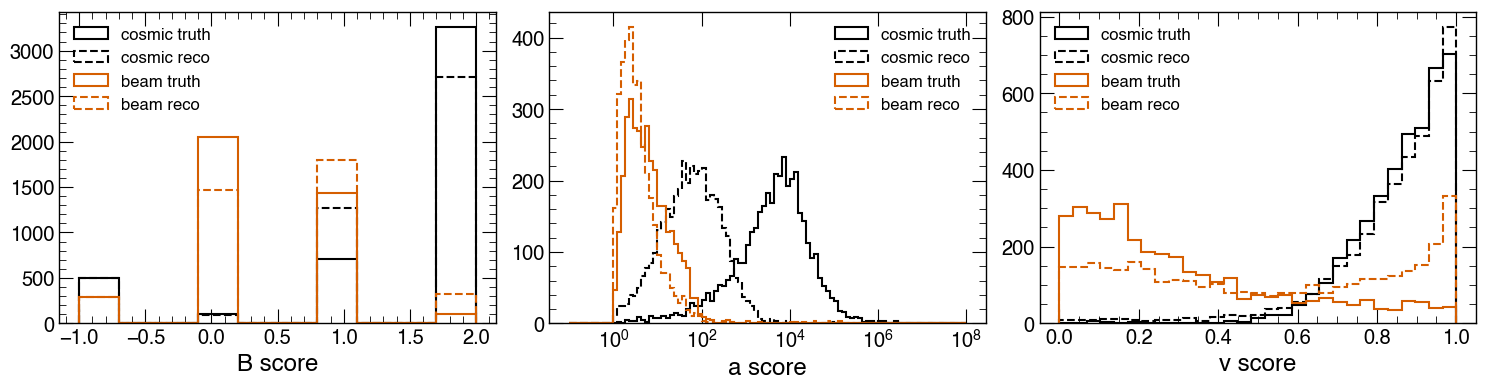

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# B score
ax = axes[0]
ax.hist(cosmic_truth.b_score, histtype='step', label='cosmic truth', color=colors[0])
ax.hist(cosmic_reco.b_score, histtype='step', label='cosmic reco', linestyle='--', color=colors[0])
ax.hist(beam_truth.b_score, histtype='step', label='beam truth', color=colors[1])
ax.hist(beam_reco.b_score, histtype='step', label='beam reco', linestyle='--', color=colors[1])
ax.set_xlabel("B score")
ax.legend()

# A score
ax = axes[1]
bins = np.logspace(-1, 8, 100)
ax.hist(cosmic_truth.a_score, histtype='step', bins=bins, color=colors[0], label='cosmic truth')
ax.hist(cosmic_reco.a_score, histtype='step', bins=bins, color=colors[0], linestyle='dashed', label='cosmic reco')
ax.hist(beam_truth.a_score, histtype='step', bins=bins, color=colors[1], label='beam truth')
ax.hist(beam_reco.a_score, histtype='step', bins=bins, color=colors[1], linestyle='dashed', label='beam reco')
ax.set_xlabel('a score')
ax.set_xscale('log')
ax.legend()

# V score
ax = axes[2]
bins = np.linspace(0, 1, 30)
ax.hist(cosmic_truth.v_score, histtype='step', bins=bins, color=colors[0], label='cosmic truth')
ax.hist(cosmic_reco.v_score, histtype='step', bins=bins, color=colors[0], linestyle='dashed', label='cosmic reco')
ax.hist(beam_truth.v_score, histtype='step', bins=bins, color=colors[1], label='beam truth')
ax.hist(beam_reco.v_score, histtype='step', bins=bins, color=colors[1], linestyle='dashed', label='beam reco')
ax.legend()
ax.set_xlabel("v score")

plt.tight_layout()
plt.show()

In [26]:
a_score = 30
print(len(cosmic_reco[(cosmic_reco.b_score>1) & (cosmic_reco.v_score>0.6)  & (cosmic_reco.a_score>a_score)])/len(cosmic_reco))
print(len(beam_reco[(beam_reco.b_score>1) & (beam_reco.v_score>0.6)  & (beam_reco.a_score>a_score)])/len(beam_reco))

0.427229020979021
0.005154639175257732


In [27]:
print(len(cosmic_truth[(cosmic_truth.b_score>1) & (cosmic_truth.v_score>0.6)  & (cosmic_truth.a_score>20)])/len(cosmic_truth))
print(len(beam_truth[(beam_truth.b_score>1) & (beam_truth.v_score>0.6)  & (beam_truth.a_score>20)])/len(beam_truth))

0.6903409090909091
0.0


In [28]:
beam_reco[(beam_reco.v_score>0.99)]

,event,run,subrun,a_score,b_score,v_score,alignment
90,8104603287906,1887,0,16.691040,1.0,0.996892,1.0
93,8104603287909,1887,0,8.151217,1.0,0.994347,1.0
132,8104603288119,1887,0,9.548440,2.0,0.992996,1.0
137,8104603288124,1887,0,2.780386,2.0,0.991568,1.0
158,8104603288205,1887,0,17.208914,2.0,0.999407,1.0
...,...,...,...,...,...,...,...
3770,36627481119128,8528,0,1.585898,2.0,0.996601,1.0
3784,36627481119212,8528,0,5.316024,1.0,0.991502,1.0
3837,36627481119516,8528,0,4.225815,0.0,0.996329,1.0
3843,36627481119662,8528,0,4.174726,2.0,0.994150,1.0


[2 3 4 5]


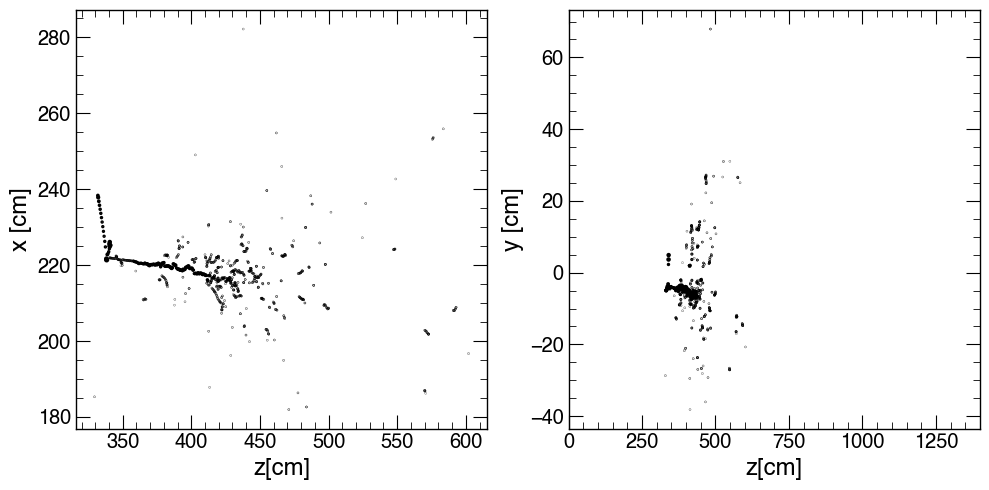

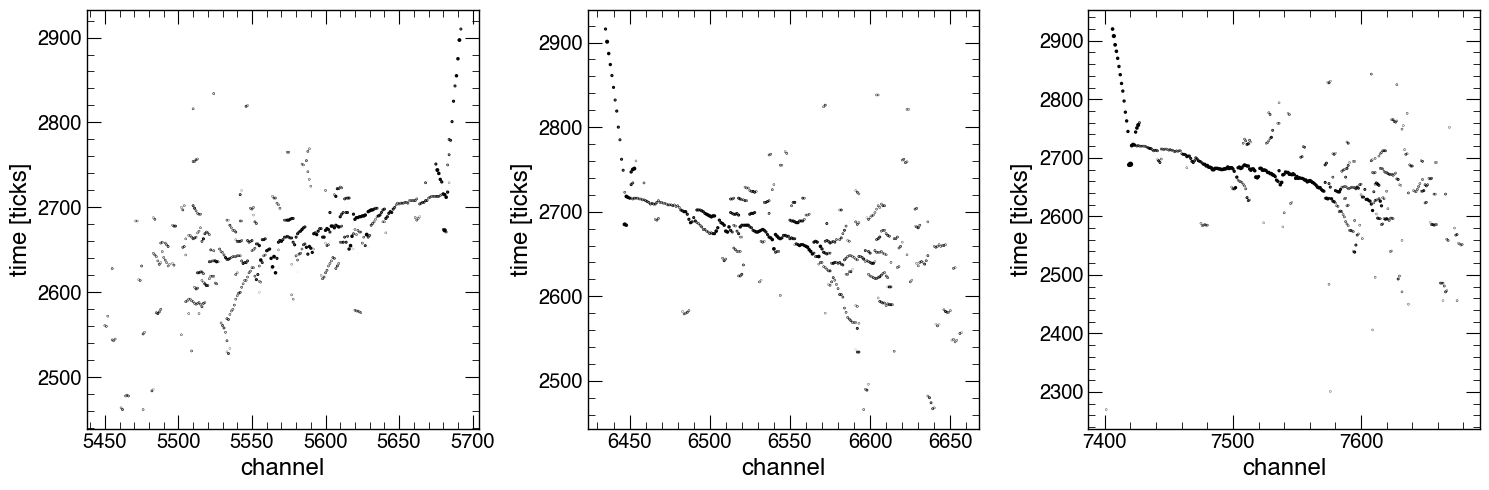

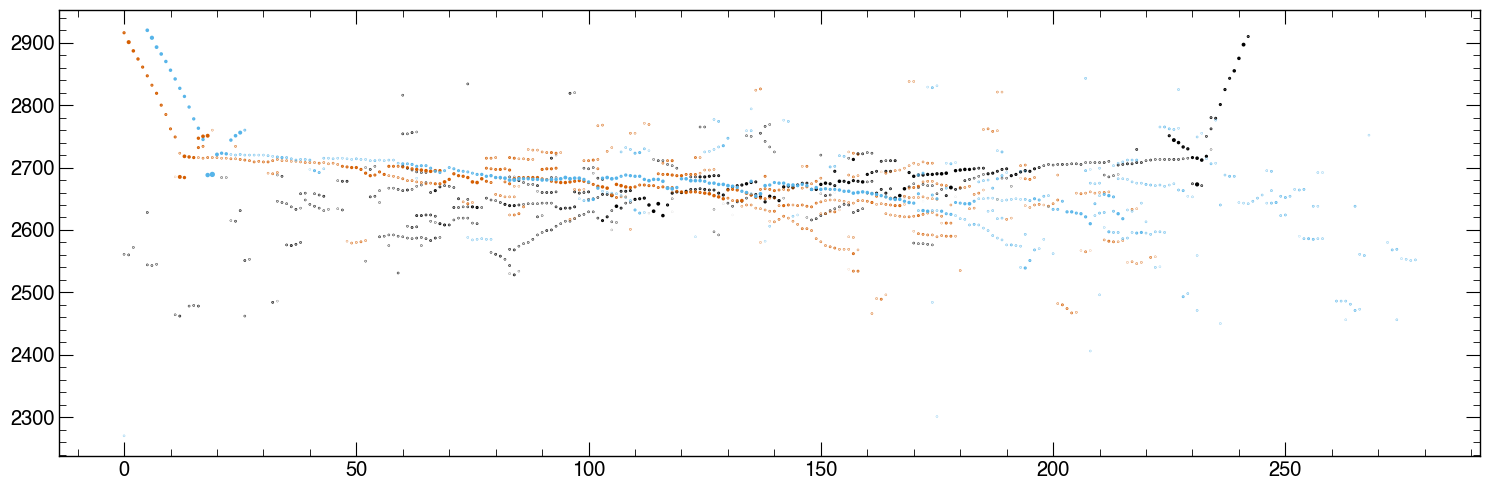

In [29]:
ev= 36627481119662
x0 = nutps0[(nutps0.event==ev) &(nutps0.bt_edep>0)]
x1 = nutps1[(nutps1.event==ev) &(nutps1.bt_edep>0)]
x2 = nutps2[(nutps2.event==ev) &(nutps2.bt_edep>0)]
print(x2.apa_id.unique())

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].scatter(x2.bt_z, x2.bt_x, s = x2.bt_edep/10)
for i in [0,1]:
    ax[i].set_xlabel("z[cm]")
ax[0].set_ylabel("x [cm]")
ax[1].scatter(x2.bt_z, x2.bt_y, s = x2.bt_edep/10)
ax[1].set_xlim(0,1400)
ax[1].set_ylabel("y [cm]")
plt.tight_layout()

plt.show()

fig,ax = plt.subplots(1,3,figsize=(15,5))
for i, df in enumerate([x0,x1,x2]):
    df = df[df.apa_id==x2.apa_id.unique()[0]]
    ax[i].scatter(df.channel, df.time_start, s = df.bt_edep/10)
    ax[i].set_xlabel("channel")
    ax[i].set_ylabel("time [ticks]")
plt.tight_layout()
plt.show()



fig,ax = plt.subplots(1,1,figsize=(15,5))
for i, df in enumerate([x0,x1,x2]):
    df = df[df.apa_id==x2.apa_id.unique()[0]]
    ax.scatter(df.channel - df.channel.min(), df.time_start, s = df.bt_edep/10)
plt.tight_layout()
plt.show()


# Case study 

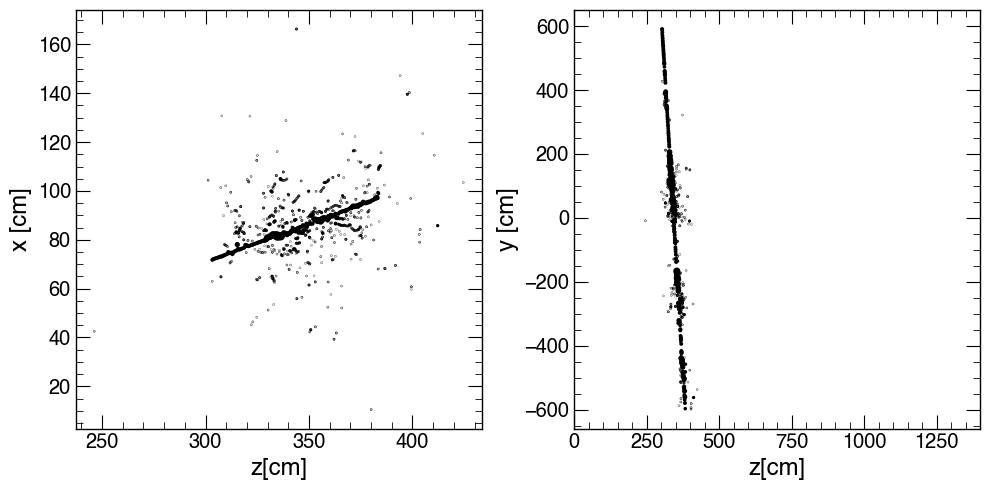

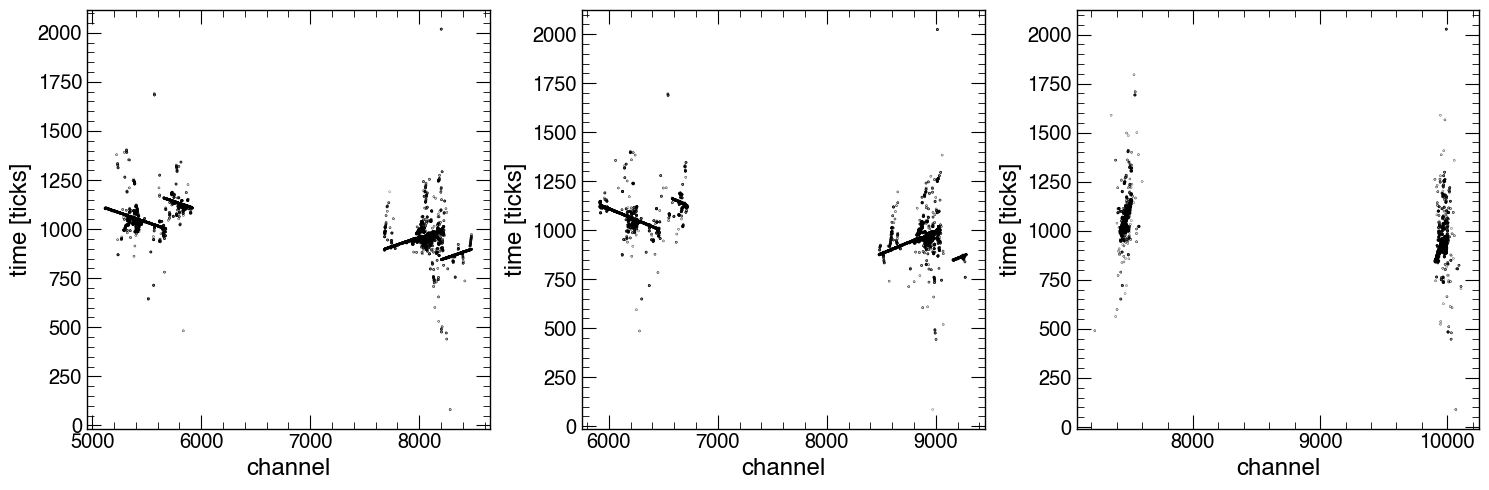

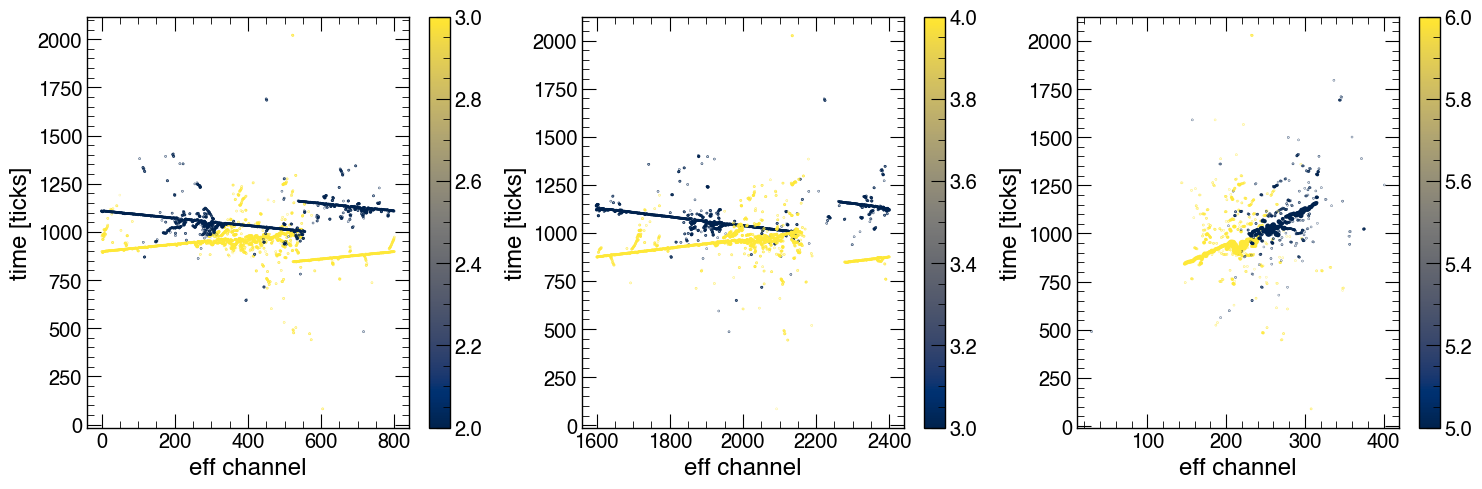

In [30]:
def get_tpc_id(apa_id, plane_id):
    return apa_id * 2 + (plane_id - 2)

def channel_offset_from_tpcid(t):
    base = 1600
    step = 2560
    ncolch = step - base
    return np.where( t % 2 == 0, base + (t // 2) * step,base + (t // 2) * step + ncolch // 2)


#map the TPC ID to a logical ix, iy, iz grid with origin at TPC0. (Assuming physical ordering that corresponds to the 1x2x6 TPC map.)
TPC_ID_TO_VOXEL = { i: (i % 2, (i // 2) % 2, i // 4) for i in range(24)}

# Invert grid mapping if needed:
VOXEL_TO_TPC_ID = {v: k for k, v in TPC_ID_TO_VOXEL.items()}


x0 = tps0[(tps0.event==42155105399233) &(tps0.bt_edep>0)]
x1 = tps1[(tps1.event==42155105399233) &(tps1.bt_edep>0)]
x2 = tps2[(tps2.event==42155105399233) &(tps2.bt_edep>0)]

for i, df in enumerate([x0,x1,x2]):
    df['tpc_id'] = get_tpc_id(df.apa_id, df.readout_plane_id)
    plane_offset = 0
    if i == 2: df['ch_in_plane'] = df.channel- channel_offset_from_tpcid(df.tpc_id) 
    if i == 0: df['ch_in_plane'] = df.channel - (df.apa_id * 2560)
    if i == 1: df['ch_in_plane'] = df.channel - (df.apa_id * 2560) + 800
    df["voxel"] = df["tpc_id"].map(TPC_ID_TO_VOXEL)
    df["it"] = (df["time_start"] // 1000).astype(int) * np.sign(df.get("bt_mu_x", 1.0))
    df["ix"] = df["voxel"].str[0].astype(int)
    df["iy"] = df["voxel"].str[1].astype(int)
    df["iz"] = df["voxel"].str[2].astype(int)
    df["eff_ch"] = df['iz']+1 * df['ch_in_plane']
    df["eff_t"] = df['it']+1 * df.time_start

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].scatter(x2.bt_z, x2.bt_x, s = x2.bt_edep/10)
for i in [0,1]:
    ax[i].set_xlabel("z[cm]")
ax[0].set_ylabel("x [cm]")
ax[1].scatter(x2.bt_z, x2.bt_y, s = x2.bt_edep/10)
ax[1].set_xlim(0,1400)
ax[1].set_ylabel("y [cm]")
plt.tight_layout()

plt.show()

fig,ax = plt.subplots(1,3,figsize=(15,5))
for i, df in enumerate([x0,x1,x2]):
    ax[i].scatter(df.channel, df.time_start, s = df.bt_edep/10)
    ax[i].set_xlabel("channel")
    ax[i].set_ylabel("time [ticks]")
plt.tight_layout()
plt.show()


fig,ax = plt.subplots(1,3,figsize=(15,5))
for i, df in enumerate([x0,x1,x2]):
    s=ax[i].scatter(df.eff_ch, df.eff_t, c=df.readout_plane_id+df.apa_id,  s = df.bt_edep/10)
    plt.colorbar(s,ax=ax[i])
    ax[i].set_xlabel("eff channel")
    ax[i].set_ylabel("time [ticks]")
plt.tight_layout()
plt.show()

In [31]:
tps2.event_uid.unique()

array([10432475705793, 10432475836865, 10432476033473, ...,
       42228119581121, 42228119712193, 42228120302017])

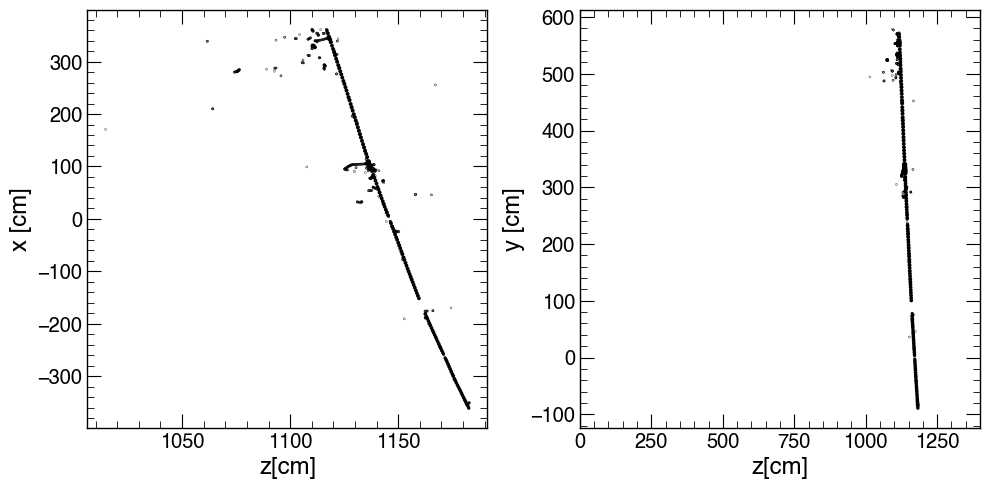

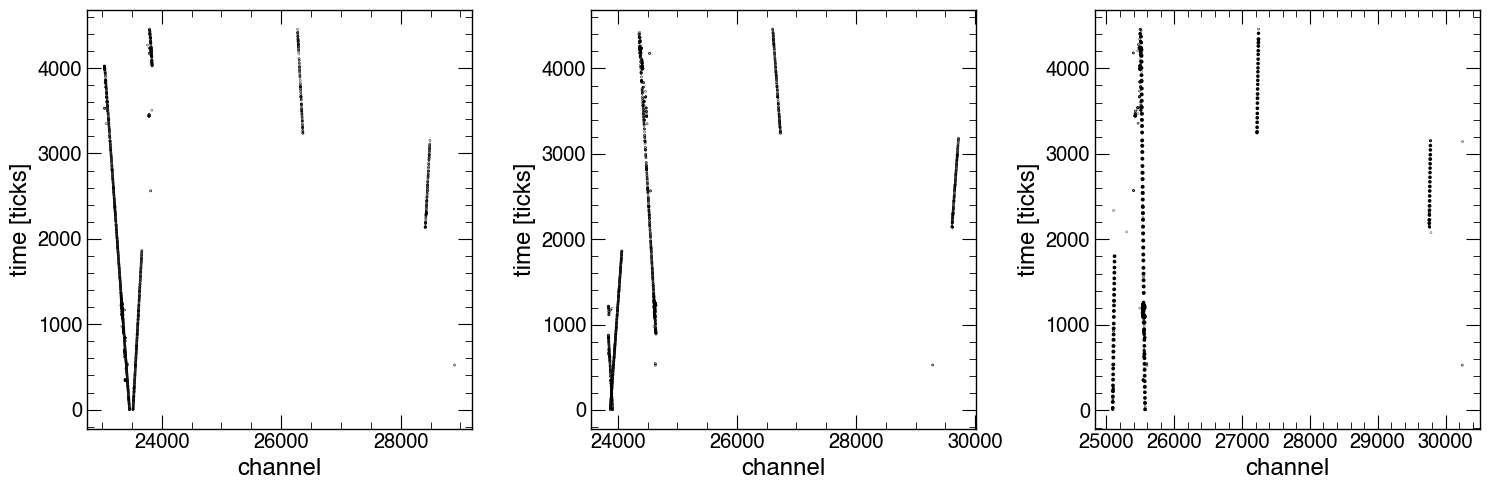

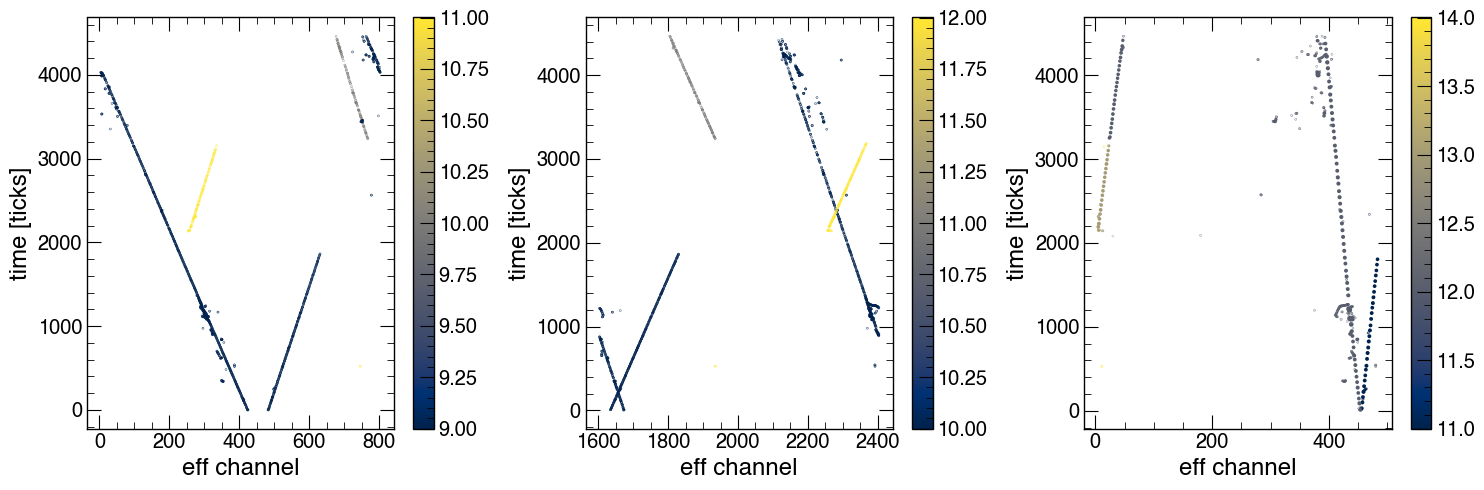

In [32]:
ev = 42228119581121

x0 = tps0[(tps0.event==ev) &(tps0.bt_edep>0)]
x1 = tps1[(tps1.event==ev) &(tps1.bt_edep>0)]
x2 = tps2[(tps2.event==ev) &(tps2.bt_edep>0)]

for i, df in enumerate([x0,x1,x2]):
    df['tpc_id'] = get_tpc_id(df.apa_id, df.readout_plane_id)
    plane_offset = 0
    if i == 2: df['ch_in_plane'] = df.channel- channel_offset_from_tpcid(df.tpc_id) 
    if i == 0: df['ch_in_plane'] = df.channel - (df.apa_id * 2560)
    if i == 1: df['ch_in_plane'] = df.channel - (df.apa_id * 2560) + 800
    df["voxel"] = df["tpc_id"].map(TPC_ID_TO_VOXEL)
    df["it"] = (df["time_start"] // 1000).astype(int) * np.sign(df.get("bt_mu_x", 1.0))
    df["ix"] = df["voxel"].str[0].astype(int)
    df["iy"] = df["voxel"].str[1].astype(int)
    df["iz"] = df["voxel"].str[2].astype(int)
    df["eff_ch"] = df['iz']+1 * df['ch_in_plane']
    df["eff_t"] = df['it']+1 * df.time_start

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].scatter(x2.bt_z, x2.bt_x, s = x2.bt_edep/10)
for i in [0,1]:
    ax[i].set_xlabel("z[cm]")
ax[0].set_ylabel("x [cm]")
ax[1].scatter(x2.bt_z, x2.bt_y, s = x2.bt_edep/10)
ax[1].set_xlim(0,1400)
ax[1].set_ylabel("y [cm]")
plt.tight_layout()

plt.show()

fig,ax = plt.subplots(1,3,figsize=(15,5))
for i, df in enumerate([x0,x1,x2]):
    ax[i].scatter(df.channel, df.time_start, s = df.bt_edep/10)
    ax[i].set_xlabel("channel")
    ax[i].set_ylabel("time [ticks]")
plt.tight_layout()
plt.show()


fig,ax = plt.subplots(1,3,figsize=(15,5))
for i, df in enumerate([x0,x1,x2]):
    s=ax[i].scatter(df.eff_ch, df.eff_t, c=df.readout_plane_id+df.apa_id,  s = df.bt_edep/10)
    plt.colorbar(s,ax=ax[i])
    ax[i].set_xlabel("eff channel")
    ax[i].set_ylabel("time [ticks]")
plt.tight_layout()
plt.show()

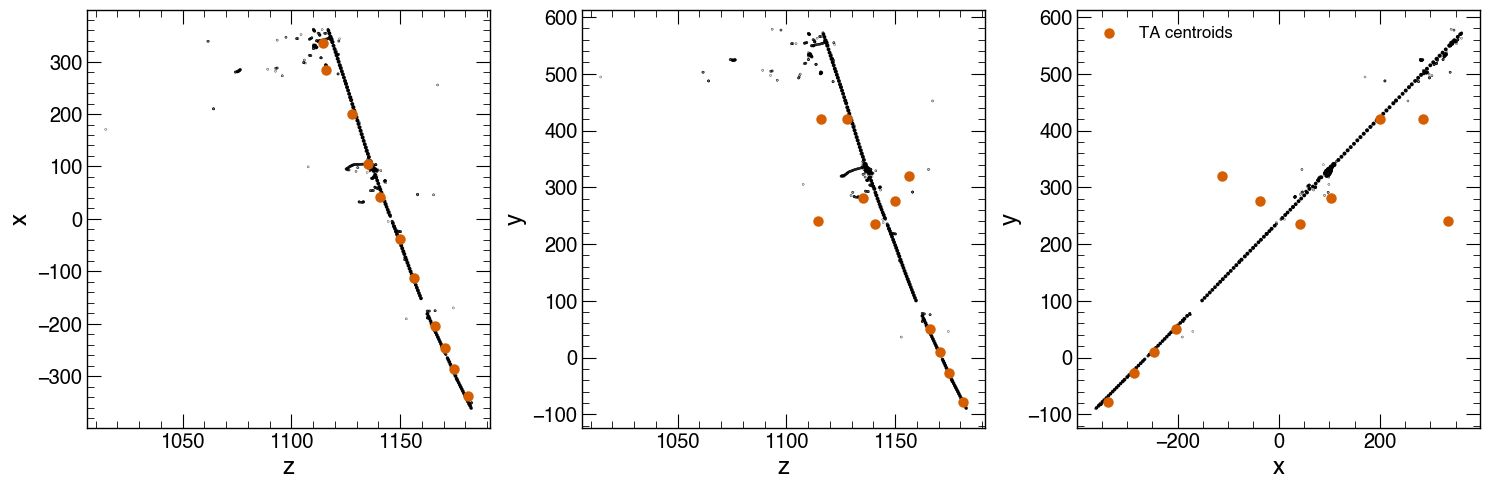

In [33]:
ev = 42228119581121
tas = reco_df[reco_df.event==ev]
x2 = tps2[(tps2.event==ev) &(tps2.bt_edep>0)]

fig,ax = plt.subplots(1,3,figsize=(15,5))
#zx
ax[0].scatter(x2.bt_z, x2.bt_x, s = x2.bt_edep/10)
ax[0].scatter(tas.z_mean, tas.x_mean)
ax[0].set_xlabel("z")
ax[0].set_ylabel("x")

#zy
ax[1].scatter(x2.bt_z, x2.bt_y, s = x2.bt_edep/10)
ax[1].scatter(tas.z_mean, tas.y_mean)
ax[1].set_xlabel("z")
ax[1].set_ylabel("y")

#xy
ax[2].scatter(x2.bt_x, x2.bt_y, s = x2.bt_edep/10)
ax[2].scatter(tas.x_mean, tas.y_mean, label = 'TA centroids')
ax[2].legend()
ax[2].set_xlabel("x")
ax[2].set_ylabel("y")
plt.tight_layout()


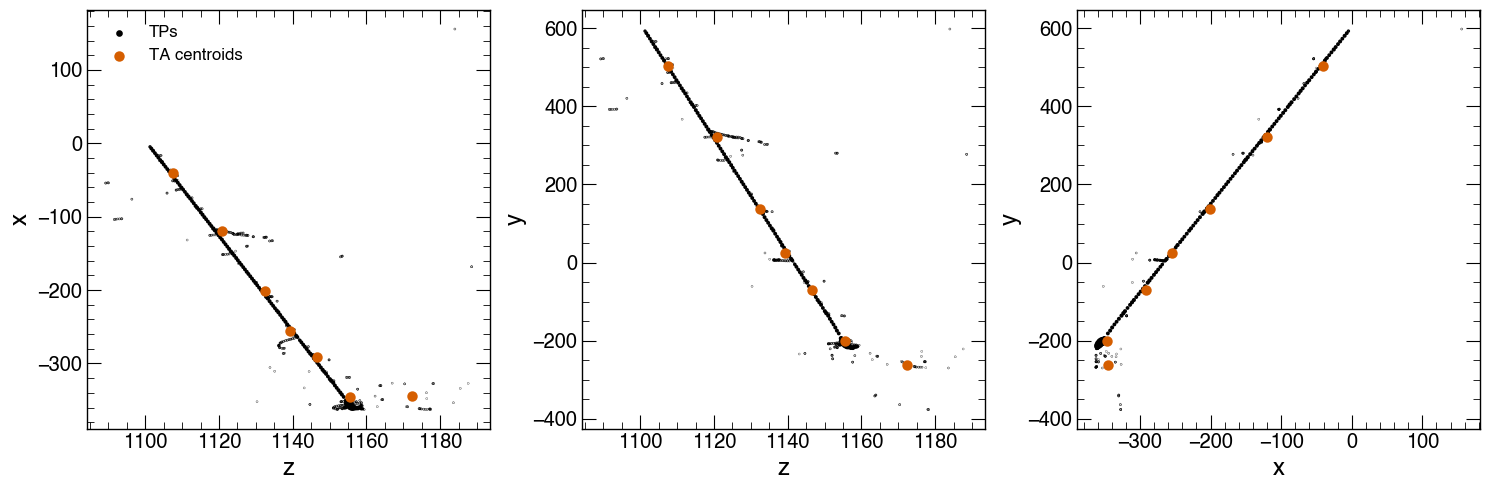

In [45]:
ev = tps2.event_uid.unique()[40]
tas = reco_df[reco_df.event==ev]
x2 = tps2[(tps2.event==ev) &(tps2.bt_edep>0)]

fig,ax = plt.subplots(1,3,figsize=(15,5))
#zx
ax[0].scatter(x2.bt_z, x2.bt_x, s = x2.bt_edep/10, label = 'TPs')
ax[0].scatter(tas.z_mean, tas.x_mean, label = 'TA centroids')
ax[0].set_xlabel("z")
ax[0].set_ylabel("x")
ax[0].legend()

#zy
ax[1].scatter(x2.bt_z, x2.bt_y, s = x2.bt_edep/10)
ax[1].scatter(tas.z_mean, tas.y_mean)
ax[1].set_xlabel("z")
ax[1].set_ylabel("y")

#xy
ax[2].scatter(x2.bt_x, x2.bt_y, s = x2.bt_edep/10)
ax[2].scatter(tas.x_mean, tas.y_mean)
ax[2].set_xlabel("x")
ax[2].set_ylabel("y")
plt.tight_layout()


In [35]:
beam_reco[beam_reco.v_score>0.99].event.values[3]

np.int64(8104603288124)

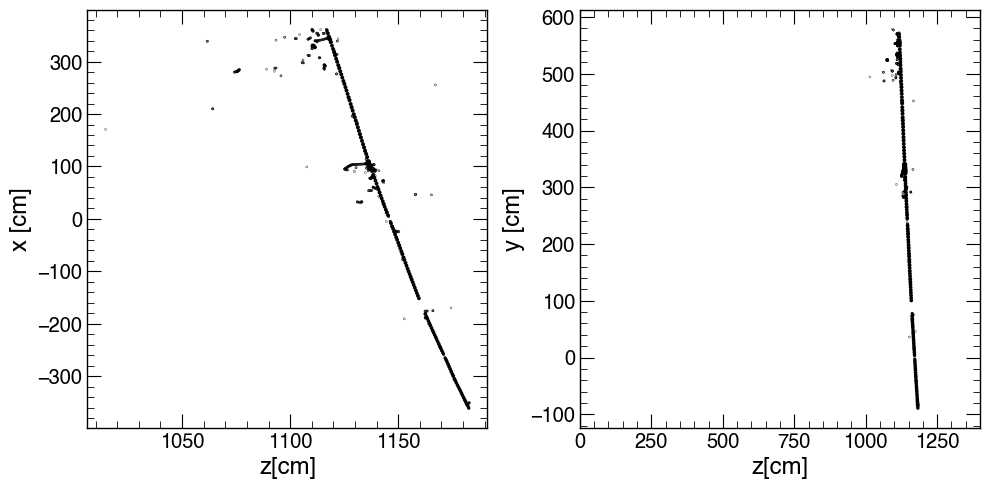

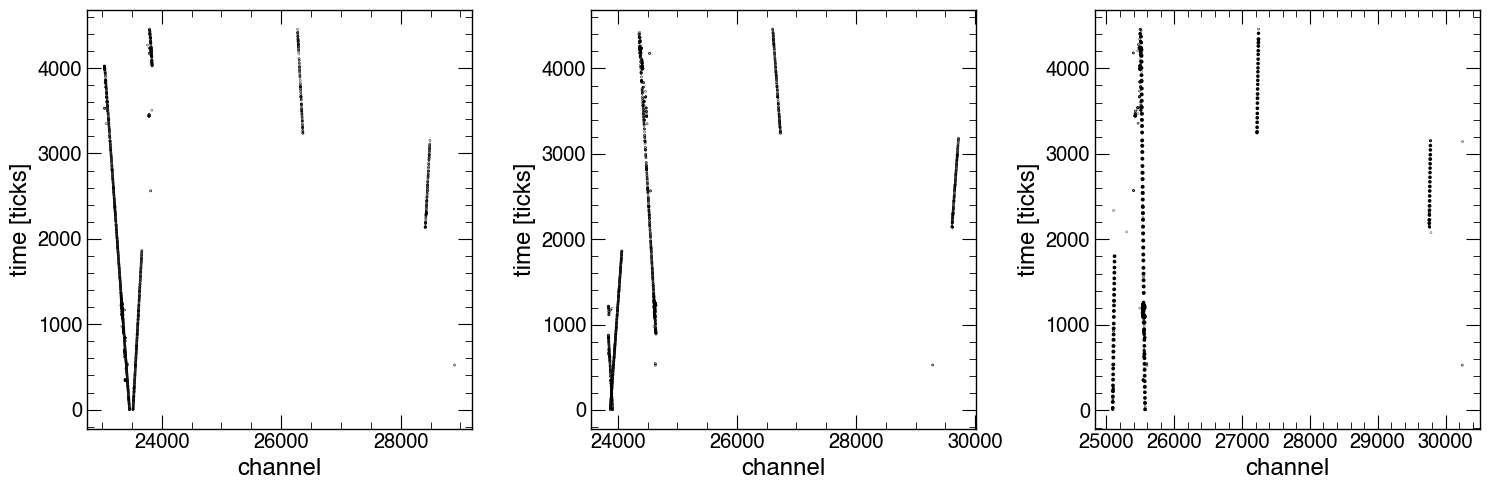

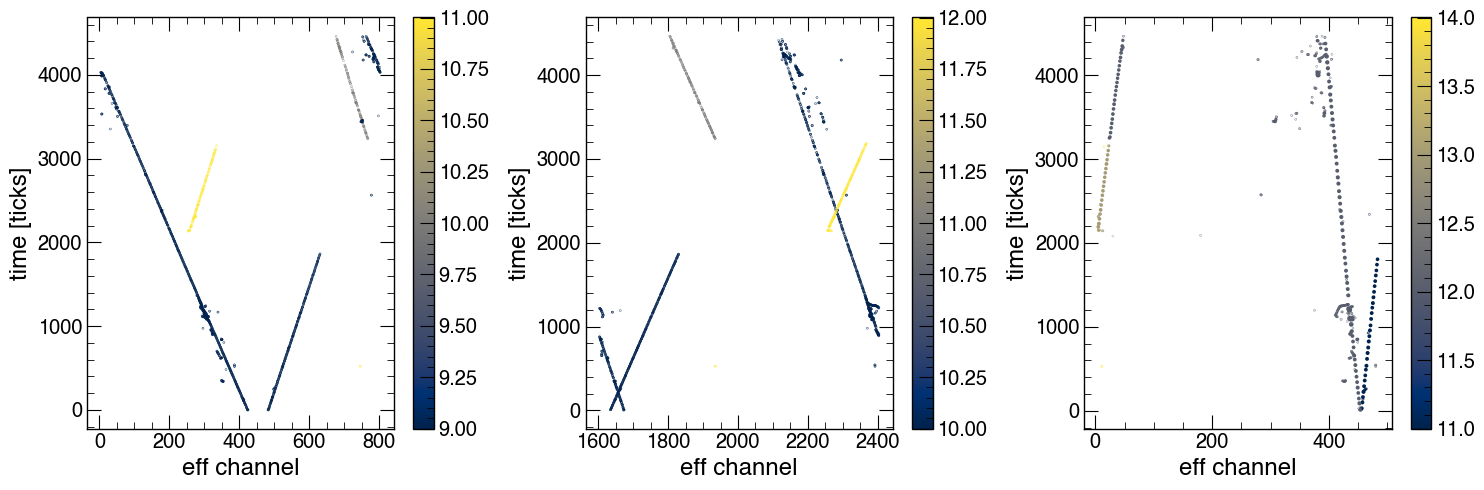

In [36]:
ev = 42228119581121

x0 = tps0[(tps0.event==ev) &(tps0.bt_edep>0)]
x1 = tps1[(tps1.event==ev) &(tps1.bt_edep>0)]
x2 = tps2[(tps2.event==ev) &(tps2.bt_edep>0)]
x0.apa_id.unique()

for i, df in enumerate([x0,x1,x2]):
    df['tpc_id'] = get_tpc_id(df.apa_id, df.readout_plane_id)
    plane_offset = 0
    if i == 2: df['ch_in_plane'] = df.channel- channel_offset_from_tpcid(df.tpc_id) 
    if i == 0: df['ch_in_plane'] = df.channel - (df.apa_id * 2560)
    if i == 1: df['ch_in_plane'] = df.channel - (df.apa_id * 2560) + 800
    df["voxel"] = df["tpc_id"].map(TPC_ID_TO_VOXEL)
    df["it"] = (df["time_start"] // 1000).astype(int) * np.sign(df.get("bt_mu_x", 1.0))
    df["ix"] = df["voxel"].str[0].astype(int)
    df["iy"] = df["voxel"].str[1].astype(int)
    df["iz"] = df["voxel"].str[2].astype(int)
    df["eff_ch"] = df['iz']+1 * df['ch_in_plane']
    df["eff_t"] = df['it']+1 * df.time_start

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].scatter(x2.bt_z, x2.bt_x, s = x2.bt_edep/10)
for i in [0,1]:
    ax[i].set_xlabel("z[cm]")
ax[0].set_ylabel("x [cm]")
ax[1].scatter(x2.bt_z, x2.bt_y, s = x2.bt_edep/10)
ax[1].set_xlim(0,1400)
ax[1].set_ylabel("y [cm]")
plt.tight_layout()

plt.show()

fig,ax = plt.subplots(1,3,figsize=(15,5))
for i, df in enumerate([x0,x1,x2]):
    ax[i].scatter(df.channel, df.time_start, s = df.bt_edep/10)
    ax[i].set_xlabel("channel")
    ax[i].set_ylabel("time [ticks]")
plt.tight_layout()
plt.show()


fig,ax = plt.subplots(1,3,figsize=(15,5))
for i, df in enumerate([x0,x1,x2]):
    s=ax[i].scatter(df.eff_ch, df.eff_t, c=df.readout_plane_id+df.apa_id,  s = df.bt_edep/10)
    plt.colorbar(s,ax=ax[i])
    ax[i].set_xlabel("eff channel")
    ax[i].set_ylabel("time [ticks]")
plt.tight_layout()
plt.show()

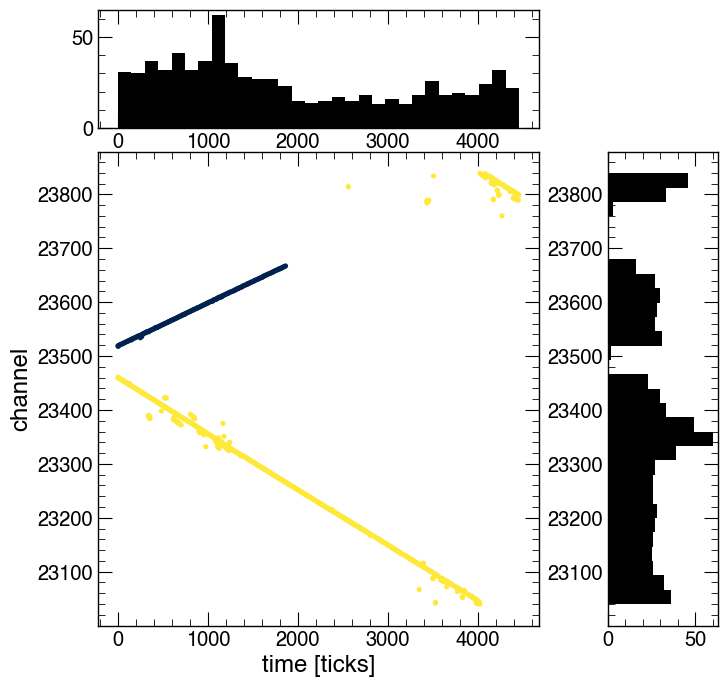

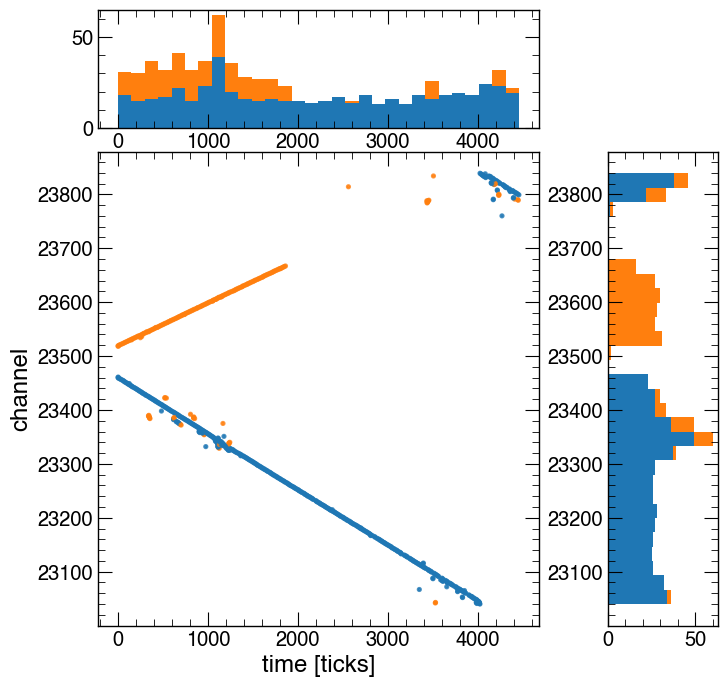

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

d = x0[x0.apa_id == 9].copy()


fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), hspace=0.08, wspace=0.25)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main,)

ax_main.scatter(d.time_start, d.channel, c=np.sign(d[d.bt_edep>0].bt_x), s=5)
ax_top.hist(d.time_start, bins=30)
ax_right.hist(d.channel, bins=30, orientation="horizontal")

ax_main.set_xlabel("time [ticks]")
ax_main.set_ylabel("channel")

plt.tight_layout()
plt.show()

times = d.time_start.values
channels = d.channel.values

# 1. Scale normalization for stable isotropic distance matching
t_scale = times.max() - times.min() + 1e-6
ch_scale = channels.max() - channels.min() + 1e-6
t_norm = times / t_scale
ch_norm = channels / ch_scale
pts_norm = np.column_stack([t_norm, ch_norm])

# 2. Extract local neighborhoods (analogous to the kernel footprint size)
num_neighbors = 10
knn = NearestNeighbors(n_neighbors=num_neighbors).fit(pts_norm)
distances, indices = knn.kneighbors(pts_norm)

# 3. Define our two candidate track direction kernels (unit vectors)
# Based on the visual trends: one goes downward (-x, -y style), one goes upward
theta1 = np.radians(-35)  # Primary downward track orientation
theta2 = np.radians(35)   # Crossing upward track orientation

u1 = np.array([np.cos(theta1), np.sin(theta1)])
u2 = np.array([np.cos(theta2), np.sin(theta2)])

# 4. Convolve neighbors with both directional kernels
activation_dir1 = np.zeros(len(times))
activation_dir2 = np.zeros(len(times))

for i, neighbors in enumerate(indices):
    # Get displacement vectors from the center hit to its neighbors
    v_diff = pts_norm[neighbors] - pts_norm[i]
    
    # Project displacements onto both direction kernels
    proj1 = v_diff @ u1
    proj2 = v_diff @ u2
    
    # Calculate alignment scores (higher means neighbors line up along that axis)
    # Using variance along the direction to measure track alignment
    activation_dir1[i] = np.var(proj1)
    activation_dir2[i] = np.var(proj2)

# 5. Classify each hit by its dominant kernel response
# If dir1 variance dominates, it's along the primary track axis; otherwise, it's the crossing track
group_labels = np.where(activation_dir1 > activation_dir2, 0, 1)

# ── Plotting ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), hspace=0.08, wspace=0.25)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

colors = np.where(group_labels == 0, "#1f77b4", "#ff7f0e")
ax_main.scatter(times, channels, c=colors, s=5, alpha=0.8)

ax_top.hist([times[group_labels == 0], times[group_labels == 1]], bins=30, stacked=True, color=["#1f77b4", "#ff7f0e"])
ax_right.hist([channels[group_labels == 0], channels[group_labels == 1]], bins=30, stacked=True, color=["#1f77b4", "#ff7f0e"], orientation="horizontal")

ax_main.set_xlabel("time [ticks]")
ax_main.set_ylabel("channel")
plt.tight_layout()
plt.show()

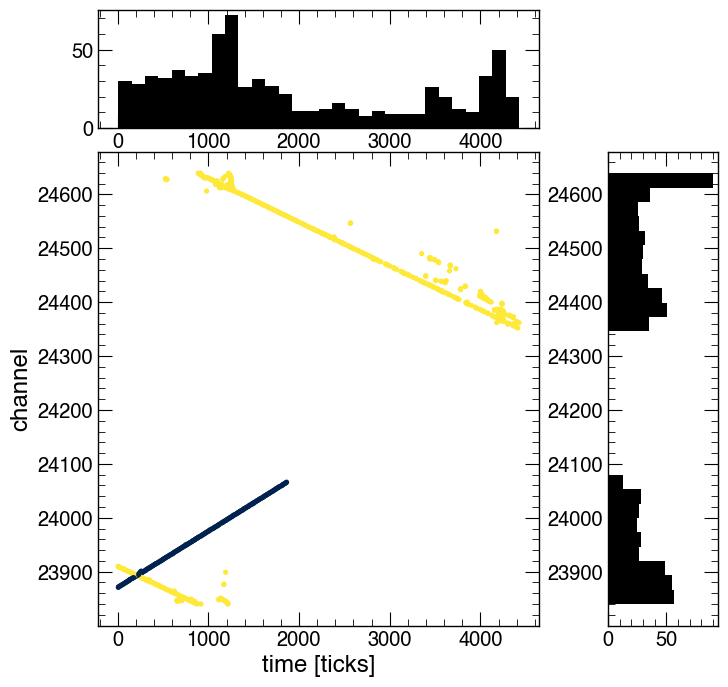

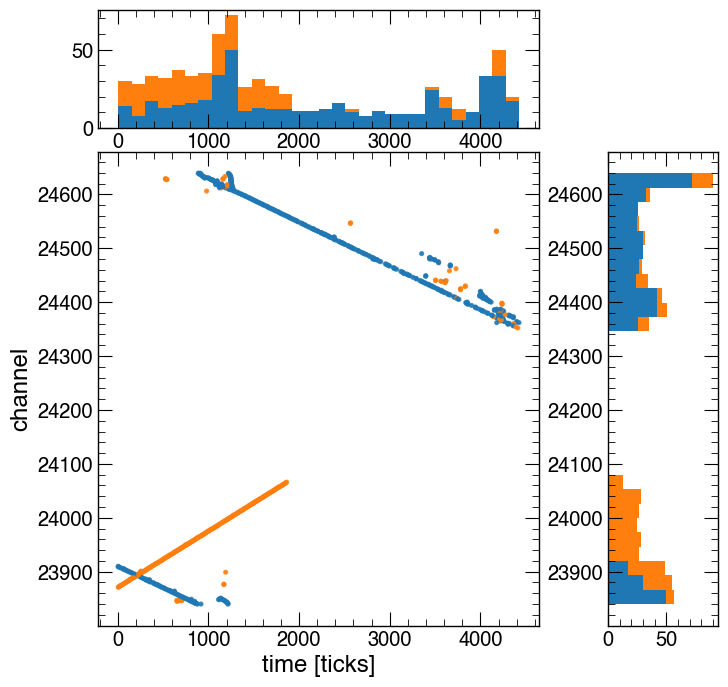

In [38]:

d = x1[x1.apa_id == 9].copy()


fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), hspace=0.08, wspace=0.25)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main,)

ax_main.scatter(d.time_start, d.channel, c=np.sign(d[d.bt_edep>0].bt_x), s=5)
ax_top.hist(d.time_start, bins=30)
ax_right.hist(d.channel, bins=30, orientation="horizontal")

ax_main.set_xlabel("time [ticks]")
ax_main.set_ylabel("channel")

plt.tight_layout()
plt.show()

times = d.time_start.values
channels = d.channel.values

# 1. Scale normalization for stable isotropic distance matching
t_scale = times.max() - times.min() + 1e-6
ch_scale = channels.max() - channels.min() + 1e-6
pts_norm = np.column_stack([times / t_scale, channels / ch_scale])

# 2. Extract local neighborhoods
num_neighbors = 10
knn = NearestNeighbors(n_neighbors=num_neighbors, algorithm='kd_tree').fit(pts_norm)
_, indices = knn.kneighbors(pts_norm)

# 3. Vectorized Directional Convolution (Zero Python Loops)
# Build a 3D tensor of neighbor displacements: shape (num_hits, num_neighbors, 2)
v_diff = pts_norm[indices] - pts_norm[:, np.newaxis, :]

# Define candidate orientation vectors
theta1, theta2 = np.radians(-35), np.radians(35)
u1 = np.array([np.cos(theta1), np.sin(theta1)])
u2 = np.array([np.cos(theta2), np.sin(theta2)])

# Project all displacements via batch dot products: shape (num_hits, num_neighbors)
proj1 = np.tensordot(v_diff, u1, axes=([2], [0]))
proj2 = np.tensordot(v_diff, u2, axes=([2], [0]))

# Compute variance across neighbors for each hit simultaneously
activation_dir1 = np.var(proj1, axis=1)
activation_dir2 = np.var(proj2, axis=1)

# 4. Binary classification based on dominant kernel response
group_labels = np.where(activation_dir1 > activation_dir2, 0, 1)

# ── Plotting ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4), hspace=0.08, wspace=0.25)

ax_top = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

colors = np.where(group_labels == 0, "#1f77b4", "#ff7f0e")
ax_main.scatter(times, channels, c=colors, s=5, alpha=0.8)

ax_top.hist([times[group_labels == 0], times[group_labels == 1]], bins=30, stacked=True, color=["#1f77b4", "#ff7f0e"])
ax_right.hist([channels[group_labels == 0], channels[group_labels == 1]], bins=30, stacked=True, color=["#1f77b4", "#ff7f0e"], orientation="horizontal")

ax_main.set_xlabel("time [ticks]")
ax_main.set_ylabel("channel")
plt.tight_layout()
plt.show()